# Twelve Years of Protection, Ordered and Clustered

In this notebook I compare terrestrial nature protection of 10 different countries. For the visualization, I chose heatmaps. I also compare two heatmap configurations, alphabetical and clustered.

**Data.** UNEP-WCMC and IUCN, *Protected Planet: WDPA and WD-OECM*, via the World Bank indicator
`ER.LND.PTLD.ZS` (terrestrial protected areas as a percentage of total land area).

This source is built for this kind of comparison, unlike the raw WDPA export used for the
choropleths. Out of the two, this one should be trusted more.


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from style import use_report_style

use_report_style()

In [2]:
protection = pd.read_csv("../data/protected_percents.csv", low_memory=False)

countries = ["FIN", "BRA", "CHN", "USA", "SWE", "GRL", "VEN", "AUS", "DEU", "JPN"]
protection = protection[protection["Country Code"].isin(countries)]

# 2010-2012 are blank for most of these countries -> remove them
protection = protection.drop(
    columns=["Country Code", "Series Name", "Series Code", "2010", "2011", "2012"]
)

protection = (
    protection.rename(columns={"Country Name": "Country"})
    .sort_values("Country")
    .set_index("Country")
    .apply(pd.to_numeric, errors="coerce")
)

protection

,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
Country,,,,,,,,,,,,
Australia,12.9,14.6,14.7,17.0,19.3,19.3,19.4,20.3,20.4,20.4,20.4,22.0
Brazil,26.4,28.5,28.5,28.9,28.9,29.4,30.3,30.3,30.3,30.3,30.6,30.6
China,17.0,17.1,17.1,17.1,17.1,15.6,15.6,15.6,15.6,15.6,15.6,15.6
Finland,14.9,15.0,15.0,15.0,15.0,15.0,13.3,13.3,13.3,13.4,13.4,13.6
Germany,37.9,37.4,37.4,37.8,37.8,37.8,37.4,37.8,37.5,37.6,37.6,39.3
Greenland,41.2,41.2,41.2,41.3,41.2,41.2,41.1,41.1,41.6,41.1,41.1,41.9
Japan,16.4,19.4,19.4,29.4,29.4,29.4,29.4,29.4,29.7,29.7,29.7,29.5
Sweden,14.6,14.8,14.9,14.5,14.9,14.9,14.4,14.5,14.5,15.4,15.4,15.5
United States,13.6,13.1,13.1,13.0,13.5,13.0,13.0,11.8,13.0,13.0,12.9,12.9


## Alphabetical

Alphabetical ordering doesn't carry any information about the data, so the order has no meaning.


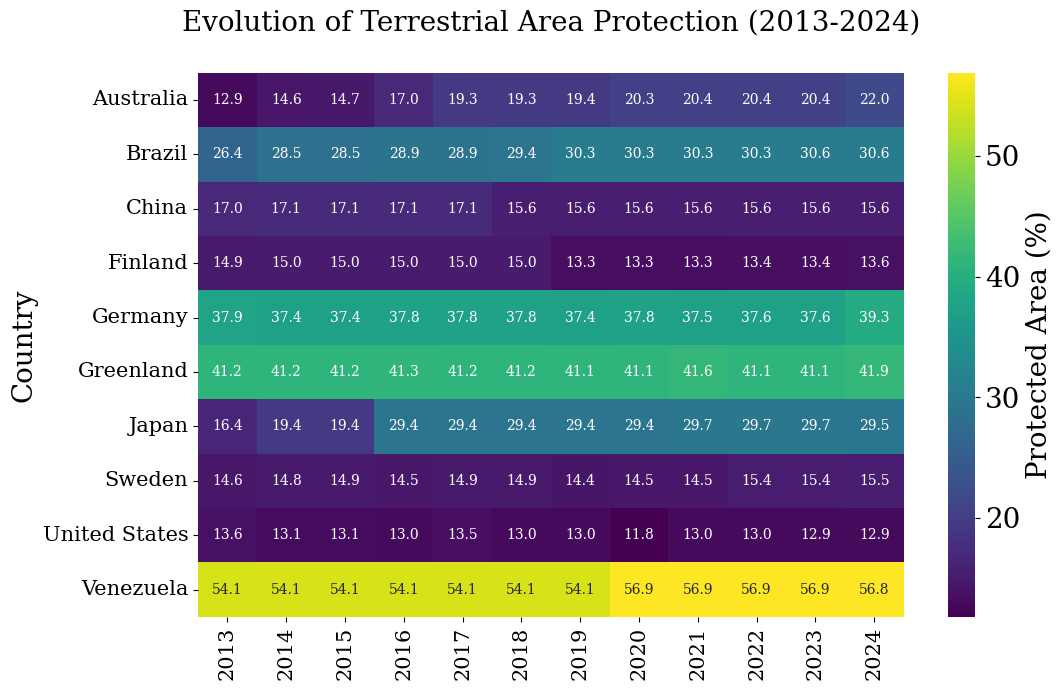

In [3]:
plt.figure(figsize=(11, 7))

sns.heatmap(
    protection,
    annot=True,
    fmt=".1f",
    cmap="viridis",
    cbar_kws={"label": "Protected Area (%)"},
)

plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.title("Evolution of Terrestrial Area Protection (2013-2024)", fontsize=20, pad=30)
plt.subplots_adjust(left=0.2)
plt.tight_layout()
plt.savefig("../figures/07-protection-heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## Clustered

Rows are reordered by hierarchical clustering. The dendrogram shows how groups are formed.


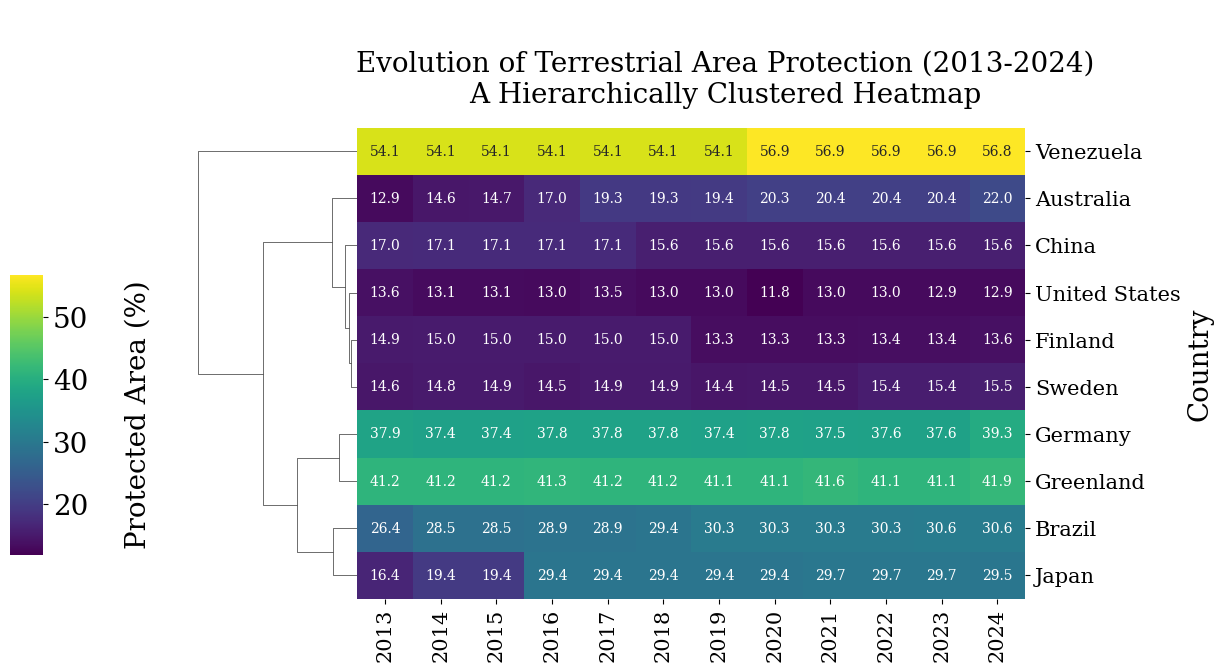

In [4]:
clustered = sns.clustermap(
    protection,
    col_cluster=False,
    annot=True,
    fmt=".1f",
    cmap="viridis",
    figsize=(11, 7),
    cbar_pos=(-0.15, 0.2, 0.03, 0.4),
    cbar_kws={"label": "\nProtected Area (%)"},
)

clustered.ax_heatmap.tick_params(axis="x", labelsize=15)
clustered.ax_heatmap.tick_params(axis="y", labelsize=15)
plt.suptitle(
    "Evolution of Terrestrial Area Protection (2013-2024)\nA Hierarchically Clustered Heatmap",
    fontsize=20, y=0.92,
)
plt.savefig("../figures/07-protection-clustermap.png", dpi=150, bbox_inches="tight")
plt.show()

## Comparison & results

Both visualizations show the evolution of terrestrial area protection for ten countries from 2013 to 2024 as a heatmap. The first visualization uses alphabetical ordering while the second one is hierarchically clustered, meaning that the vertical order is based on how close they are to each other. The dendrogram on the left side of the second visualization shows the clustering method. For example, Venezuela is separated from the others in the first step as there is such a large difference between Venezuela and the rest. Venezuela is clearly ahead of the other countries with Greenland, Germany, Brazil and Japan coming next. It seems that the percentage of protected areas rises as time goes on, indicating positive progress towards SDG 15. This dataset contradicts the previous one since China was behind Finland in the [previous notebook](06-protected-area-choropleths.ipynb). This dataset should be trusted more. A different time scale (e.g., decades) could be used to show development on a larger scale over a longer time period.

The second visualization is more intuitive to me since countries are clustered and different clusters can be compared in addition to individual countries. The larger clusters can be pre-attentively processed, making it faster to process the visualization. However, the dendrogram can be confusing at first.

**Design notes:**

I selected an ordered color scale called viridis. It uses both hue and luminance to indicate the value. It primarily contains shades of blue, green and yellow, meaning that dichromacy should not affect its perception. I used annotation with one decimal to show individual values, making it easier to compare individual cells.

I picked countries based on the results of the [previous notebook](06-protected-area-choropleths.ipynb) as well as their impact and how interesting they are. Making the heatmap was quite straightforward as I only needed to make small changes regarding font sizes and positioning, for example. For the clustermap, I disabled column clustering to preserve the temporal structure and chose the default method for calculating clusters since it seemed intuitive.
